In [5]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.7 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Pengaturan visualisasi
plt.style.use("seaborn-v0_8")
np.random.seed(42)

In [14]:
# --- 1. Pembuatan Dataset Sintetis ---
N = 600

# Variabel Input
RPM = np.random.uniform(1000, 7000, N)
Load = np.random.uniform(10, 90, N)

# Variabel Output (Engine Temperature/Temp)
# Menggunakan model non-linear untuk sintesis data
Temp = (
    30
    + 0.004 * (RPM - 2000)
    + 0.09 * Load
    + 0.5 * np.sin((RPM / 7000) * 2 * np.pi)
    + 0.02 * Load * (RPM / 7000)
    + np.random.normal(0, 1.2, N)
)

data = pd.DataFrame({"RPM": RPM, "Load": Load, "Temp": Temp})
data.head() # Menampilkan 5 data teratas

,RPM,Load,Temp
0,5129.645415,53.908693,46.337536
1,1843.317805,33.010618,33.280978
2,3913.538198,34.542128,42.429367
3,1165.220319,38.236680,30.046332
4,4032.730707,59.703396,43.100552


In [15]:
data.tail()

,RPM,Load,Temp
595,5996.982261,24.627022,47.268608
596,6436.522363,76.056876,55.282416
597,1072.940629,32.856605,29.263716
598,5044.119514,84.169903,49.900145
599,1311.014795,87.594122,34.411158


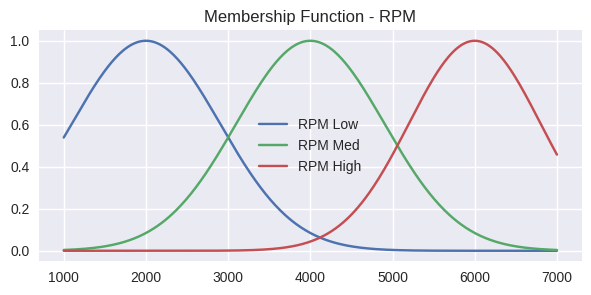

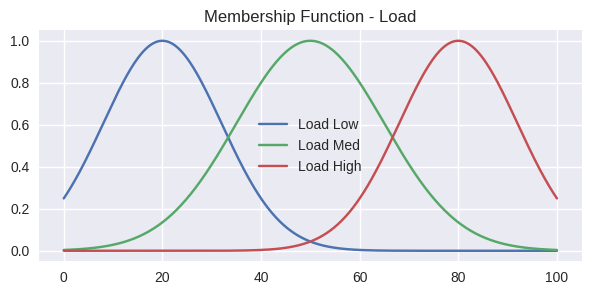

In [8]:
# --- 2. Visualisasi Fungsi Keanggotaan ---

# Domain untuk RPM (1000 sampai 7000)
x_rpm = np.linspace(1000, 7000, 400)
# Fungsi keanggotaan Gaussian (gaussmf) untuk RPM (Low, Med, High)
rpm_low = fuzz.gaussmf(x_rpm, 2000, 900)
rpm_med = fuzz.gaussmf(x_rpm, 4000, 900)
rpm_high = fuzz.gaussmf(x_rpm, 6000, 800)

plt.figure(figsize=(7, 3))
plt.plot(x_rpm, rpm_low, label="RPM Low")
plt.plot(x_rpm, rpm_med, label="RPM Med")
plt.plot(x_rpm, rpm_high, label="RPM High")
plt.legend()
plt.title("Membership Function - RPM")
plt.show()

# Domain untuk Load (0 sampai 100)
x_load = np.linspace(0, 100, 400)
# Fungsi keanggotaan Gaussian untuk Load (Low, Med, High)
load_low = fuzz.gaussmf(x_load, 20, 12)
load_med = fuzz.gaussmf(x_load, 50, 15)
load_high = fuzz.gaussmf(x_load, 80, 12)

plt.figure(figsize=(7, 3))
plt.plot(x_load, load_low, label="Load Low")
plt.plot(x_load, load_med, label="Load Med")
plt.plot(x_load, load_high, label="Load High")
plt.legend()
plt.title("Membership Function - Load")
plt.show()

In [9]:
# --- 3. Implementasi Kelas ANFISManual ---

class ANFISManual:
    def __init__(self, n_inputs=2, n_mfs=3, lr=0.02):
        self.n_inputs = n_inputs # Jumlah variabel input (RPM, Load)
        self.n_mfs = n_mfs       # Jumlah fungsi keanggotaan per input (Low, Med, High)
        self.lr = lr             # Learning Rate (tidak digunakan dalam metode lstsq)

        # Inisialisasi parameter fungsi keanggotaan (centers dan sigmas)
        # Menggunakan nilai ternormalisasi (0 hingga 1)
        self.centers = np.array([
            np.linspace(0.1, 0.9, n_mfs) for _ in range(n_inputs)
        ])
        self.sigmas = np.array([
            np.ones(n_mfs) * 0.15 for _ in range(n_inputs)
        ])

        # Jumlah aturan (misal: 3 input * 3 input = 9 aturan)
        self.n_rules = n_mfs ** n_inputs

        # Membuat indeks untuk setiap aturan (misal: (0,0), (0,1), ..., (2,2))
        grids = np.meshgrid(*[np.arange(n_mfs) for _ in range(n_inputs)])
        self.rule_indices = np.vstack([g.flatten() for g in grids]).T

        # Inisialisasi parameter konsekuen Sugeno (p, q, r, ...)
        # Ukuran: n_rules x (n_inputs + 1) -> 9 x 3
        self.W = np.zeros((self.n_rules, n_inputs + 1))

    def _gauss(self, x, c, s):
        """Fungsi Keanggotaan Gaussian"""
        # Note: Rumus di file tampaknya memiliki kesalahan ketik (harus: -0.5 * ...)
        # Menggunakan rumus Gaussian yang benar: exp(-0.5 * ((x-c)/s)**2)
        # Sesuai dengan implementasi skfuzzy yang biasa digunakan untuk ANFIS.
        return np.exp(-0.5 * ((x - c) / s) ** 2)

    def _firing(self, Xn):
        """Menghitung Derajat Keanggotaan dan Firing Strength (Layer 1 & 2)"""
        N = Xn.shape[0]
        F = np.zeros((N, self.n_rules))

        for r in range(self.n_rules):
            prod = np.ones(N) # Inisialisasi untuk operator T-norm (AND)
            for i in range(self.n_inputs):
                # Ambil indeks MF untuk input ke-i pada rule ke-r
                idx = self.rule_indices[r, i]

                # Hitung derajat keanggotaan
                mu = self._gauss(Xn[:, i], self.centers[i, idx], self.sigmas[i, idx])

                # T-norm (Perkalian/AND)
                prod = prod * mu

            F[:, r] = prod
        return F

    def predict(self, Xn):
        """Menghitung Prediksi Output (Layer 4 & 5)"""

        # Firing Strength (Layer 2)
        F = self._firing(Xn)

        # Normalisasi Firing Strength (Layer 3)
        # Wn = F_i / (Σ F_j)
        Wn = F / (F.sum(1, keepdims=True) + 1e-8)

        # Input yang diperluas [x1, x2, ..., x_n, 1]
        Xext = np.hstack([Xn, np.ones((Xn.shape[0], 1))])

        # Output Konsekuen Sugeno untuk setiap aturan (Layer 4)
        # y_rules = [w_i,1, w_i,2, ..., w_i,n+1] @ [x1, x2, ..., x_n, 1]^T
        y_rules = Xext @ self.W.T

        # Total Output (Layer 5)
        # y = Σ (Wn_i * y_rules_i)
        y = (Wn * y_rules).sum(axis=1, keepdims=True)

        return y, F, Wn

    def fit(self, Xn, y, epochs=30):
        """Melatih model ANFIS menggunakan Least Squares Estimate (LSE)"""
        history = []
        N = Xn.shape[0]

        for ep in range(epochs):
            # 1. Forward pass & Hitung Normalized Firing Strength (Wn)
            F = self._firing(Xn)
            Wn = F / (F.sum(1, keepdims=True) + 1e-8)
            Xext = np.hstack([Xn, np.ones((N, 1))])

            # 2. Konstruksi matriks Phi (Regressors) untuk LSE
            # Phi berukuran N x (n_rules * (n_inputs + 1))
            Phi = np.zeros((N, self.n_rules * (self.n_inputs + 1)))

            for r in range(self.n_rules):
                s = r * (self.n_inputs + 1)
                # Phi_i,j = Wn_i * Xext (untuk rule r)
                Phi[:, s:s + self.n_inputs + 1] = Wn[:, r:r + 1] * Xext

            # 3. LSE: Hitung parameter konsekuen W
            # W = (Phi^T Phi)^-1 Phi^T y
            # Menggunakan np.linalg.lstsq
            Theta, _, _, _ = np.linalg.lstsq(Phi, y, rcond=None)

            # Reshape hasil Theta (parameter konsekuen) kembali ke W
            self.W = Theta.reshape(self.n_rules, self.n_inputs + 1)

            # 4. Hitung Loss (MSE)
            y_pred, _, _ = self.predict(Xn)
            loss = ((y - y_pred) ** 2).mean()
            history.append(loss)

            if (ep + 1) % 5 == 0:
                print(f"Epoch {ep+1}/{epochs} Loss: {loss:.4f}")

        return history

In [10]:
# --- 4. Persiapan Data dan Pelatihan Model ---

# Ekstrak Input (X) dan Output (Y)
X = data[['RPM', 'Load']].values
Y = data['Temp'].values.reshape(-1, 1)

# Normalisasi: Penting untuk fungsi keanggotaan yang diinisialisasi pada [0, 1]
Xmin = X.min(0)
Xmax = X.max(0)
normalize = lambda X: (X - Xmin) / (Xmax - Xmin + 1e-8)

Xn = normalize(X)

# Split Data (Training dan Testing)
Xtr, Xte, ytr, yte = train_test_split(Xn, Y, test_size=0.2, random_state=42)

# Inisialisasi dan Latih Model ANFIS
anfis = ANFISManual()
history = anfis.fit(Xtr, ytr, epochs=30)

Epoch 5/30 Loss: 1.3987
Epoch 10/30 Loss: 1.3987
Epoch 15/30 Loss: 1.3987
Epoch 20/30 Loss: 1.3987
Epoch 25/30 Loss: 1.3987
Epoch 30/30 Loss: 1.3987


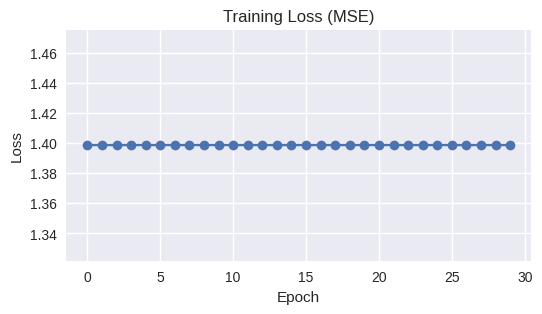

In [11]:
# --- 5. Visualisasi Training Loss ---

plt.figure(figsize=(6, 3))
plt.plot(history, marker='o')
plt.title("Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


--- Evaluasi Model Testing ---
MSE: 1.5344
R²: 0.9747


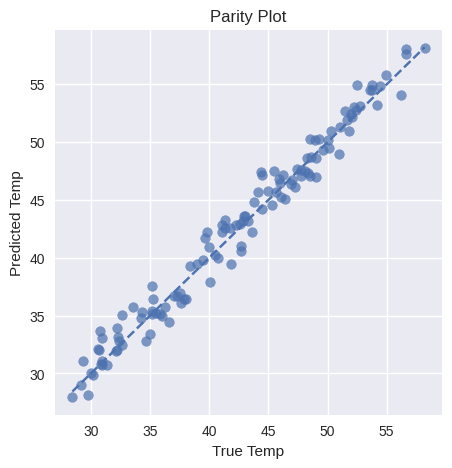

In [12]:
# --- 6. Evaluasi Model ---

# Prediksi pada Data Testing
y_pred, _, _ = anfis.predict(Xte)

# Metrik Evaluasi
print("\n--- Evaluasi Model Testing ---")
print(f"MSE: {mean_squared_error(yte, y_pred):.4f}")
print(f"R²: {r2_score(yte, y_pred):.4f}")

# Visualisasi Parity Plot
plt.figure(figsize=(5, 5))
plt.scatter(yte, y_pred, alpha=0.7)
mn, mx = yte.min(), yte.max()
plt.plot([mn, mx], [mn, mx], '--') # Garis ideal (y_true = y_pred)
plt.xlabel("True Temp")
plt.ylabel("Predicted Temp")
plt.title("Parity Plot")
plt.grid(True)
plt.show()

In [13]:
# --- 7. Prediksi pada Seluruh Data dan Sampel ---

# Lakukan prediksi pada seluruh data
data['Temp_Pred'] = anfis.predict(normalize(data[['RPM', 'Load']].values))[0].flatten()

# Tampilkan 10 sampel data (True vs Predicted Temp)
print("\n--- Contoh Sampel Prediksi ---")
print(data.sample(10))


--- Contoh Sampel Prediksi ---
             RPM       Load       Temp  Temp_Pred
433  1606.736057  19.645351  31.476233  30.805565
150  6449.595316  19.351843  51.460469  49.788386
12   5994.655845  60.232031  50.502364  52.327957
492  2664.287098  58.618944  39.365899  38.371429
295  4133.459560  26.398744  41.448827  40.838735
228  6352.279331  69.000100  53.771060  54.914395
566  3353.464271  76.570734  44.954980  43.362549
192  6402.508343  50.471094  54.146842  53.199707
486  1272.678282  59.072911  32.304662  34.175700
186  5903.333201  56.671344  51.433652  51.521619
